# xml: html처럼 태그 기반으로 자료를 저장한 포멧
* xml parser를 통해서 str을 xml로 변환하는 작업이 필요
* xml로 변환이 되면 태그 기반으로 자료를 찾아서 정리
* 태크에서 자료를 추출할 때는 beautifulsoup이라는 라이브러리를 이용

# 전세대출 데이터 수집

In [1]:
import os
import requests
import pandas as pd
import time

In [4]:
servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
url = "http://apis.data.go.kr/B551408/rent-loan-rate-info/rate-list"
payload = dict(servicekey = servicekey, numOfRows = 20, pageNo = 1, dataType = "JSON")
r = requests.get(url, params=payload)
response = r.json()
# response =r.text # 기본은 text로 온다
response

{'header': {'resultCode': '00', 'resultMsg': '정상'},
 'body': {'pageNo': 1,
  'totalCount': 18,
  'numOfRows': 20,
  'items': [{'bssYmdStart': '20250324',
    'interest4_1': '0',
    'interest3_2': '0',
    'interest4_2': '0',
    'interest2_1': '0',
    'interest1_2': '0',
    'interest3_1': '0',
    'interest2_2': '0',
    'interest1_1': '0',
    'bssYmdEnd': '20250330',
    'organId': '산업은행',
    'callCenter': '1588-1500'},
   {'bssYmdStart': '20250324',
    'interest4_1': '0',
    'interest3_2': '0',
    'interest4_2': '0',
    'interest2_1': '0',
    'interest1_2': '0',
    'interest3_1': '0',
    'interest2_2': '0',
    'interest1_1': '0',
    'bssYmdEnd': '20250330',
    'organId': '제주은행',
    'callCenter': '1588-0079'},
   {'bssYmdStart': '20250324',
    'interest4_1': '0',
    'interest3_2': '0',
    'interest4_2': '0',
    'interest2_1': '0',
    'interest1_2': '0',
    'interest3_1': '0',
    'interest2_2': '0',
    'interest1_1': '0',
    'bssYmdEnd': '20250330',
    'organI

In [57]:
len(response['body']['items'])

18

In [53]:
result={}
for item in response['body']['items']:
    for key, value in item.items():
        result.setdefault(key, []).append(value)

df = pd.DataFrame(result)
df

,bssYmdStart,interest4_1,interest3_2,interest4_2,interest2_1,interest1_2,interest3_1,interest2_2,interest1_1,bssYmdEnd,organId,callCenter
0,20250310,0,0,0,0,0,0,0,0,20250316,산업은행,1588-1500
1,20250310,0,0,0,0,0,0,0,0,20250316,제주은행,1588-0079
2,20250310,0,0,0,0,0,0,0,0,20250316,SC은행,1588-1599
3,20250310,4.89,0,0,0,0,0,0,0,20250316,전북은행,1588-4477
4,20250310,0,0,0,0,0,0,0,0,20250316,수협은행,1588-1515
5,20250310,4.26,0,0,0,0,0,0,0,20250316,우리은행,1599-5000
6,20250310,4.64,0,0,0,0,0,0,0,20250316,경남은행,1588-8585
7,20250310,3.5,0,0,0,0,0,0,0,20250316,카카오뱅크,1599-3333
8,20250310,3.38,0,0,0,0,0,0,0,20250316,아이엠뱅크,1588-5050
9,20250310,4.18,0,0,0,0,0,0,0,20250316,하나은행,1599-1111


### 파싱
* 일반 문자열이 아닌, 특정 문서 형식으로 변환하는 것
* 문자열 => xml, 문자열 => html
* **일반 문자열을 DOM tree 구조로 변환한다!**

# xml로 가져오기

In [5]:
servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
url = "http://apis.data.go.kr/B551408/rent-loan-rate-info/rate-list"
payload = dict(servicekey = servicekey, numOfRows = 20, pageNo = 1, dataType = "XML")
r = requests.get(url, params=payload)
response = r.text
response

'<response><header><resultCode>00</resultCode><resultMsg>정상</resultMsg></header><body><pageNo>1</pageNo><totalCount>18</totalCount><numOfRows>20</numOfRows><items><item><bssYmdStart>20250324</bssYmdStart><interest4_1>0</interest4_1><interest3_2>0</interest3_2><interest4_2>0</interest4_2><interest2_1>0</interest2_1><interest1_2>0</interest1_2><interest3_1>0</interest3_1><interest2_2>0</interest2_2><interest1_1>0</interest1_1><bssYmdEnd>20250330</bssYmdEnd><organId>산업은행</organId><callCenter>1588-1500</callCenter></item><item><bssYmdStart>20250324</bssYmdStart><interest4_1>0</interest4_1><interest3_2>0</interest3_2><interest4_2>0</interest4_2><interest2_1>0</interest2_1><interest1_2>0</interest1_2><interest3_1>0</interest3_1><interest2_2>0</interest2_2><interest1_1>0</interest1_1><bssYmdEnd>20250330</bssYmdEnd><organId>제주은행</organId><callCenter>1588-0079</callCenter></item><item><bssYmdStart>20250324</bssYmdStart><interest4_1>0</interest4_1><interest3_2>0</interest3_2><interest4_2>0</inte

* xml로 데이터를 받으면 처음에는 단순 문자열로 받게 된다.
* 문자열을 xml 문서로 변환해야 함(파싱)
* 문자열을 DOM TREE로 변환한다
* beautifulsoup을 이용해 변환
* beautifulsoup의 메서드인 select, select_one을 이용해 셀렉터 기반으로 데이터가 위치한 태그를 찾아서 추출

In [ ]:
!pip install beautifulsoup4

# BeautifulSoup

* 파싱해주는 라이브러리
* https://www.crummy.com/software/BeautifulSoup/bs4/doc/ 참고
* **설치방법: pip install beautifulsoup4**
* from bs4 import BeautifulSoup as bs
* find, find_all 함수: xml, html 에서 태그 기반으로 내용을 찾음
* **select, select_one**함수: xml, html에서 css selector 기반으로 내용을 찾음
* find_all, select는 해당 태그나 css selector를 가진 부분을 모두 찾아서 list로 반환
* find, select_one은 여러 태그나 css selector 중에서 가장 먼저 나오는 태그/selector를 한 개만 찾아줌
* 찾아온 태그 .name: 태그 이름 반환
* 찾아온 태그 .text or .string: 태그 안쪽의 텍스트 반환

In [ ]:
!pip install lxml

In [6]:
from bs4 import BeautifulSoup as bs

In [7]:
soup = bs(response, 'xml')
print(soup)

<?xml version="1.0" encoding="utf-8"?>
<response><header><resultCode>00</resultCode><resultMsg>정상</resultMsg></header><body><pageNo>1</pageNo><totalCount>18</totalCount><numOfRows>20</numOfRows><items><item><bssYmdStart>20250324</bssYmdStart><interest4_1>0</interest4_1><interest3_2>0</interest3_2><interest4_2>0</interest4_2><interest2_1>0</interest2_1><interest1_2>0</interest1_2><interest3_1>0</interest3_1><interest2_2>0</interest2_2><interest1_1>0</interest1_1><bssYmdEnd>20250330</bssYmdEnd><organId>산업은행</organId><callCenter>1588-1500</callCenter></item><item><bssYmdStart>20250324</bssYmdStart><interest4_1>0</interest4_1><interest3_2>0</interest3_2><interest4_2>0</interest4_2><interest2_1>0</interest2_1><interest1_2>0</interest1_2><interest3_1>0</interest3_1><interest2_2>0</interest2_2><interest1_1>0</interest1_1><bssYmdEnd>20250330</bssYmdEnd><organId>제주은행</organId><callCenter>1588-0079</callCenter></item><item><bssYmdStart>20250324</bssYmdStart><interest4_1>0</interest4_1><interest3

### select 

* css 전체 테그에서 특정 테그만 추출하고 싶을 때
* xml이 담긴 객체.select(특정 태그)

In [8]:
soup.select_one("totalCount")

<totalCount>18</totalCount>

In [9]:
items = soup.select_one('items')
items.select_one("bssYmdStart").name

'bssYmdStart'

In [10]:
items = soup.select_one('items')
item = items.select("item")
bssYmdStart_list = items.select("bssYmdStart")

In [11]:
bssYmdStart_list

[<bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>,
 <bssYmdStart>20250324</bssYmdStart>]

In [12]:
soup.select("item")[0]

<item><bssYmdStart>20250324</bssYmdStart><interest4_1>0</interest4_1><interest3_2>0</interest3_2><interest4_2>0</interest4_2><interest2_1>0</interest2_1><interest1_2>0</interest1_2><interest3_1>0</interest3_1><interest2_2>0</interest2_2><interest1_1>0</interest1_1><bssYmdEnd>20250330</bssYmdEnd><organId>산업은행</organId><callCenter>1588-1500</callCenter></item>

In [13]:
for bank in soup.select("organId"):
    print(bank.name, bank.text)

organId 산업은행
organId 제주은행
organId SC은행
organId 경남은행
organId 수협은행
organId 우리은행
organId 전북은행
organId 카카오뱅크
organId 아이엠뱅크
organId 하나은행
organId 토스뱅크
organId 케이뱅크
organId 기업은행
organId 부산은행
organId 농협은행
organId 국민은행
organId 광주은행
organId 신한은행


In [14]:
for tag in items.select_one("item"):
    print(tag.name)

bssYmdStart
interest4_1
interest3_2
interest4_2
interest2_1
interest1_2
interest3_1
interest2_2
interest1_1
bssYmdEnd
organId
callCenter


In [16]:
items = soup.select_one('items')
bssYmdStart_list = items.select("bssYmdStart")
interest4_1_list = items.select("interest4_1")
interest3_2_list = items.select("interest3_2")
interest4_2_list = items.select("interest4_2")
interest2_1_list = items.select("interest2_1")
interest1_2_list = items.select("interest1_2")
interest3_1_list = items.select("interest3_1")
interest2_2_list = items.select("interest2_2")
interest1_1_list = items.select("interest1_1")
bssYmdEnd_list = items.select("bssYmdEnd")
organId_list = items.select("organId")
callCenter_list = items.select("callCenter")

In [18]:
tag_list = [bssYmdStart_list, interest4_1_list, interest3_2_list, interest4_2_list, interest2_1_list, interest1_2_list, interest3_1_list, interest2_2_list, interest1_1_list, bssYmdEnd_list, organId_list, callCenter_list]

In [ ]:
result = {}
for lists in tag_list:
    for item in lists:
        result.setdefault(item.name, []).append(item.text)
result

In [20]:
df = pd.DataFrame(result)
df

,bssYmdStart,interest4_1,interest3_2,interest4_2,interest2_1,interest1_2,interest3_1,interest2_2,interest1_1,bssYmdEnd,organId,callCenter
0,20250324,0,0,0,0,0,0,0,0,20250330,산업은행,1588-1500
1,20250324,0,0,0,0,0,0,0,0,20250330,제주은행,1588-0079
2,20250324,0,0,0,0,0,0,0,0,20250330,SC은행,1588-1599
3,20250324,0,0,0,0,0,0,0,0,20250330,경남은행,1588-8585
4,20250324,0,0,0,0,0,0,0,0,20250330,수협은행,1588-1515
5,20250324,4.28,0,0,0,0,0,0,0,20250330,우리은행,1599-5000
6,20250324,4.76,0,0,0,0,0,0,0,20250330,전북은행,1588-4477
7,20250324,3.54,0,0,0,0,0,0,0,20250330,카카오뱅크,1599-3333
8,20250324,3.32,0,0,0,0,0,0,0,20250330,아이엠뱅크,1588-5050
9,20250324,4.19,0,0,0,0,0,0,0,20250330,하나은행,1599-1111


In [21]:
result= {}
items = soup.select_one('items')
bssYmdStart_list = items.select("bssYmdStart")
interest4_1_list = items.select("interest4_1")
interest3_2_list = items.select("interest3_2")
interest4_2_list = items.select("interest4_2")
interest2_1_list = items.select("interest2_1")
interest1_2_list = items.select("interest1_2")
interest3_1_list = items.select("interest3_1")
interest2_2_list = items.select("interest2_2")
interest1_1_list = items.select("interest1_1")
bssYmdEnd_list = items.select("bssYmdEnd")
organId_list = items.select("organId")
callCenter_list = items.select("callCenter")

# 반복문으로 태그를 자동 추출해서 만들기

In [ ]:
for tag in soup.select("items")[0]:
    for key in tag:
        print(key.name, key.text)

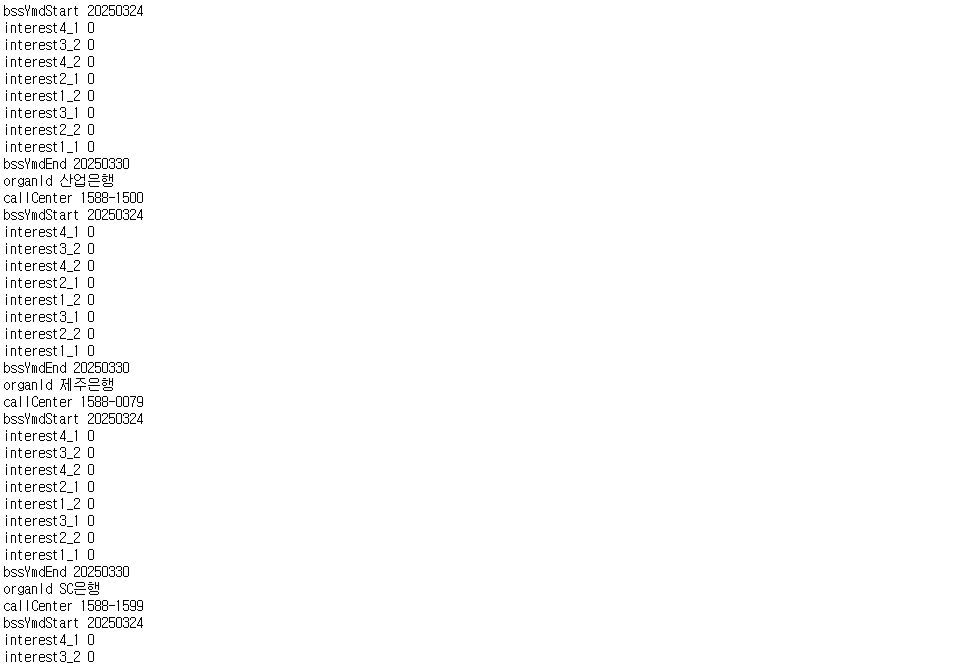

In [23]:
result = {}
for tags in soup.select("item"):
        for tag in tags:
            result.setdefault(tag.name, []).append(tag.text)
            
df = pd.DataFrame(result)
df

,bssYmdStart,interest4_1,interest3_2,interest4_2,interest2_1,interest1_2,interest3_1,interest2_2,interest1_1,bssYmdEnd,organId,callCenter
0,20250324,0,0,0,0,0,0,0,0,20250330,산업은행,1588-1500
1,20250324,0,0,0,0,0,0,0,0,20250330,제주은행,1588-0079
2,20250324,0,0,0,0,0,0,0,0,20250330,SC은행,1588-1599
3,20250324,0,0,0,0,0,0,0,0,20250330,경남은행,1588-8585
4,20250324,0,0,0,0,0,0,0,0,20250330,수협은행,1588-1515
5,20250324,4.28,0,0,0,0,0,0,0,20250330,우리은행,1599-5000
6,20250324,4.76,0,0,0,0,0,0,0,20250330,전북은행,1588-4477
7,20250324,3.54,0,0,0,0,0,0,0,20250330,카카오뱅크,1599-3333
8,20250324,3.32,0,0,0,0,0,0,0,20250330,아이엠뱅크,1588-5050
9,20250324,4.19,0,0,0,0,0,0,0,20250330,하나은행,1599-1111


In [32]:
for item in soup.select("items"):
    for tags in item.select("item"):
        print(tags.name)

item
item
item
item
item
item
item
item
item
item
item
item
item
item
item
item
item
item


In [26]:
items.select

<bound method Tag.select of <items><item><bssYmdStart>20250324</bssYmdStart><interest4_1>0</interest4_1><interest3_2>0</interest3_2><interest4_2>0</interest4_2><interest2_1>0</interest2_1><interest1_2>0</interest1_2><interest3_1>0</interest3_1><interest2_2>0</interest2_2><interest1_1>0</interest1_1><bssYmdEnd>20250330</bssYmdEnd><organId>산업은행</organId><callCenter>1588-1500</callCenter></item><item><bssYmdStart>20250324</bssYmdStart><interest4_1>0</interest4_1><interest3_2>0</interest3_2><interest4_2>0</interest4_2><interest2_1>0</interest2_1><interest1_2>0</interest1_2><interest3_1>0</interest3_1><interest2_2>0</interest2_2><interest1_1>0</interest1_1><bssYmdEnd>20250330</bssYmdEnd><organId>제주은행</organId><callCenter>1588-0079</callCenter></item><item><bssYmdStart>20250324</bssYmdStart><interest4_1>0</interest4_1><interest3_2>0</interest3_2><interest4_2>0</interest4_2><interest2_1>0</interest2_1><interest1_2>0</interest1_2><interest3_1>0</interest3_1><interest2_2>0</interest2_2><interes

# xml에 있는 모든 key를 추출하기

In [33]:
tag_names = []
for tags in soup.select("*"):
    tag_names.append(tags.name)
len(tag_names)

243

In [ ]:
tag_names = []
for items in soup.select("item"):
    for item in items:
        tag_names.append(item.name)
tag_names

# 집합자료형 set : 중복 없는 데이터 집합 만들기
* 중복을 제거한다(중복 제거 시 원래 순서 유지되지 않음)

In [124]:
tags = set(tag_names)
tags

{'body',
 'bssYmdEnd',
 'bssYmdStart',
 'callCenter',
 'header',
 'interest1_1',
 'interest1_2',
 'interest2_1',
 'interest2_2',
 'interest3_1',
 'interest3_2',
 'interest4_1',
 'interest4_2',
 'item',
 'items',
 'numOfRows',
 'organId',
 'pageNo',
 'response',
 'resultCode',
 'resultMsg',
 'totalCount'}

# 공공데이터 서민대출 데이터 수집

# json 데이터 정리하기

In [ ]:
result_list = []
page = 1
while True:
    url = "https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo"
    servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
    payload = dict(servicekey = servicekey, numOfRows = 1000, pageNo = page, resultType = "json")
    r = requests.get(url, params=payload)
    response = r.json()
    response
    total_pages = (response['response']['body']['totalCount'] // response['response']['body']['numOfRows']) + 1
    result = {}
    for item in response['response']['body']['items']['item']:
        for key, value in item.items():
            result.setdefault(key, []).append(value)
    df = pd.DataFrame(result)
    result_list.append(df)
    
    if page < total_pages:
        page += 1
    else:
        break
        
result_df = pd.concat(result_list)
result_df = result_df.reset_index(drop=True)
result_df

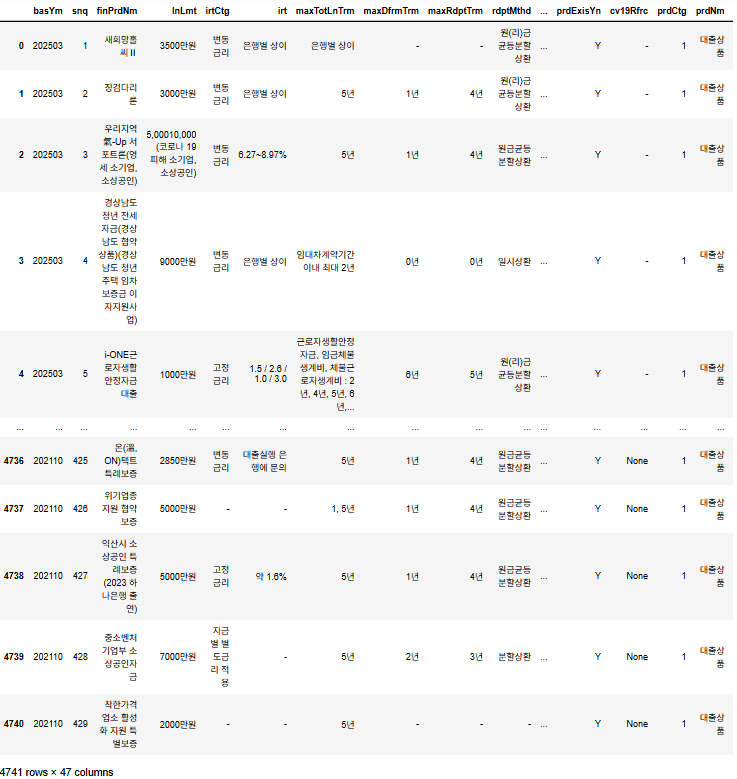

In [43]:
response['response']['body']['numOfRows']

1000

In [44]:
response['response']['body']['totalCount']

4741

In [ ]:
result = {}
for item in response['response']['body']['items']['item']:
    for key, value in item.items():
        result.setdefault(key, []).append(value)
df = pd.DataFrame(result)
df

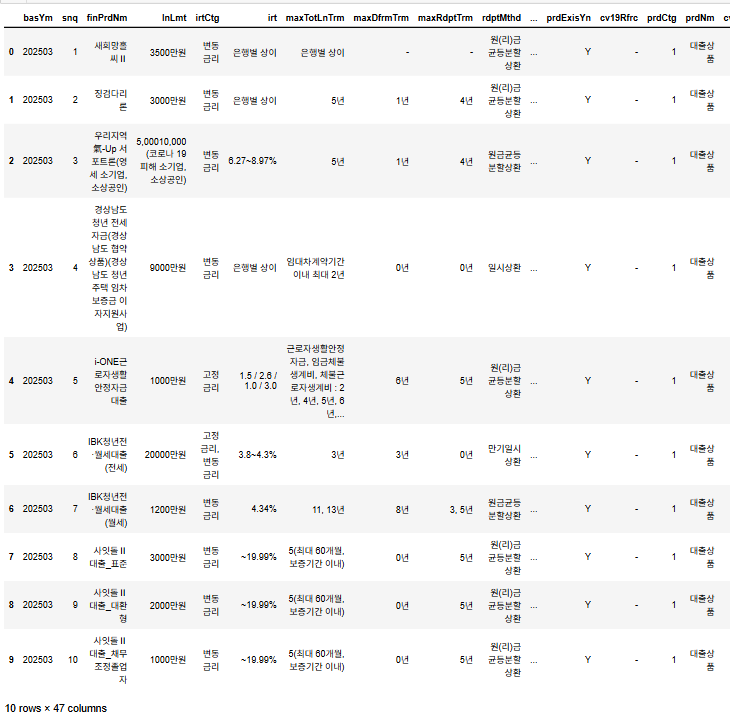

# xml 데이터 정리하기

In [ ]:
xml_result_df_list = []
page = 1
while True:
    url = "https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo"
    servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
    payload = dict(servicekey = servicekey, numOfRows = 1000, pageNo = page, resultType = "xml")
    r = requests.get(url, params=payload)
    print(r.url)
    print(r.status_code)
    response = r.content # 파싱할 때는 content가 text 보다 좋다
    soup = bs(response, "xml") # 파싱하기
    xml_result = {}
    for item in soup.select('item'):
        for tags in item:
            if tags.name == None:
                continue
            else:
                xml_result.setdefault(tags.name, []).append(tags.text)
    xml_result_df_list.append(pd.DataFrame(xml_result))
    numOfRows = int(soup.select_one("numOfRows").text)
    totalCount = int(soup.select_one("totalCount").text)
    total_pages = totalCount // numOfRows + 1
    if page < total_pages:
        page += 1
    else:
        break
        
xml_result_df_list = pd.concat(xml_result_df_list)
xml_result_df_list = xml_result_df_list.reset_index(drop=True)
xml_result_df_list

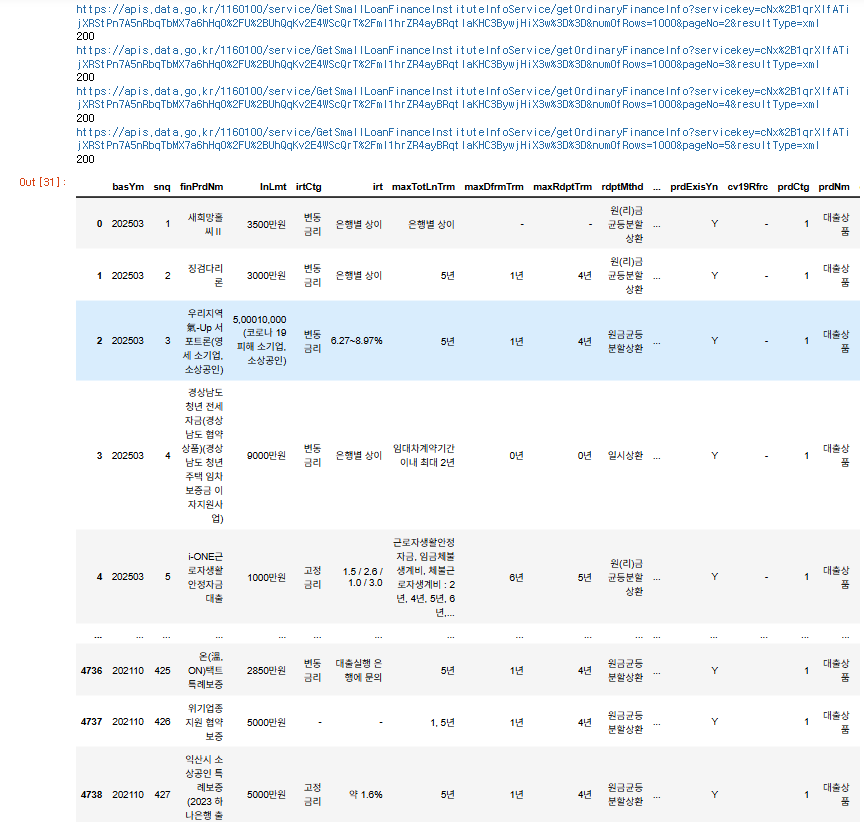

In [ ]:
numOfRows = int(soup.select_one("numOfRows").text)
totalCount = int(soup.select_one("totalCount").text)
total_pages = totalCount // numOfRows + 1

setdefault를 이용해 xml의 tag명의 유일값 추출하기

In [9]:
tag_names = {}
for tags in soup.select("*"):
    tag_names.setdefault(tags.name, "")
for tag_name in tag_names.keys():
    print(tag_name)

response
header
resultCode
resultMsg
body
numOfRows
pageNo
totalCount
items
item
basYm
snq
finPrdNm
lnLmt
irtCtg
irt
maxTotLnTrm
maxDfrmTrm
maxRdptTrm
rdptMthd
usge
trgt
instCtg
ofrInstNm
rsdAreaPamtEqltIstm
suprTgtDtlCond
age
incm
rsdArea
crdtSc
anin
housHoldCnt
housAr
lnTgtHous
rfrcCnpl
grnInst
jnMthd
rpymdCfe
lnIcdcst
ovItrYr
prftAddIrtCond
etcRefSbjc
hdlInst
cnpl
rltSite
tgtFltr
hdlInstDtlVw
prdExisYn
cv19Rfrc
prdCtg
prdNm
cv19SuprCtg
cv19SuprCtn
cv19SuprTgtDtlCtn
mgmDln
prdCtg2
fileWrtDt


In [ ]:
xml_result = {}
for item in soup.select('item'):
    for tags in item:
        if tags.name == None:
            continue
        else:
            xml_result.setdefault(tags.name, []).append(tags.text)

xml_result_df = pd.DataFrame(xml_result)
xml_result_df

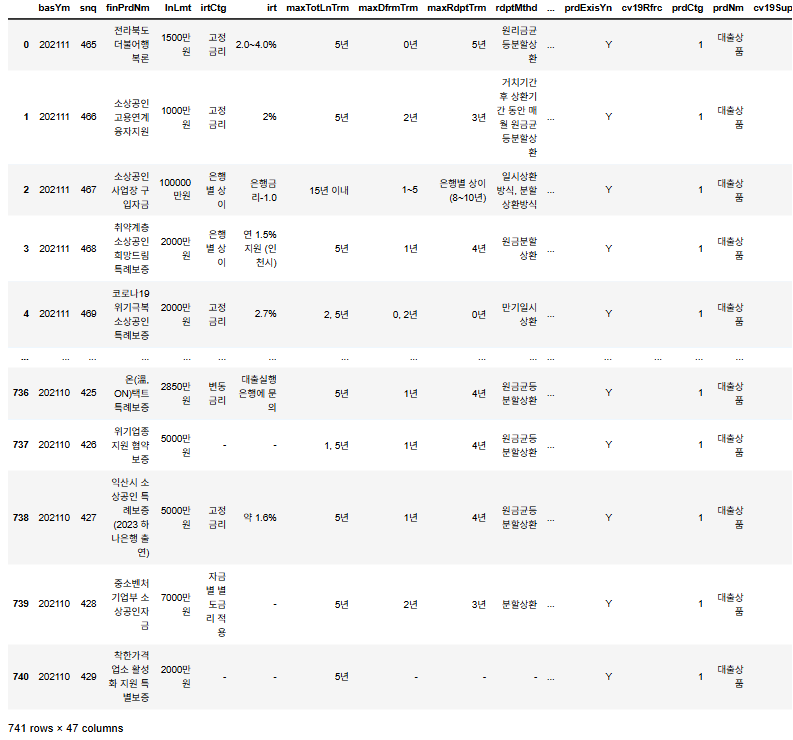

# key_list를 만들고 select로 직접 추출하기 

In [ ]:
df_list = []
page = 1
while True:
    url = "https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo"
    servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
    payload = dict(servicekey = servicekey, numOfRows = 1000, pageNo = page, resultType = "xml")
    r = requests.get(url, params=payload)
    print(r.url)
    print(r.status_code)
    numOfRows = int(soup.select_one("numOfRows").text)
    totalCount = int(soup.select_one("totalCount").text)
    total_pages =  totalCount / numOfRows
    response = r.content # 파싱할 때는 text 보다 좋다 (BeautifultSoup에 넣을 때는 r.content 쓰는 걸로 이해하자)
    soup = bs(response, "xml")
    key_list = {}
    for item in soup.select("*"):
        key_list.setdefault(item.name, "")
    keys = list(key_list.keys())
    result = {}
    for key in keys[10:]:
        for item in soup.select(key):
            result.setdefault(item.name, []).append(item.text)
    df_list.append(pd.DataFrame(result)) 
    if page < total_pages:
        page += 1
    else:
        print("데이터 수집완료")
        break
result_df = pd.concat(df_list)
result_df = result_df.reset_index(drop=True)
result_df

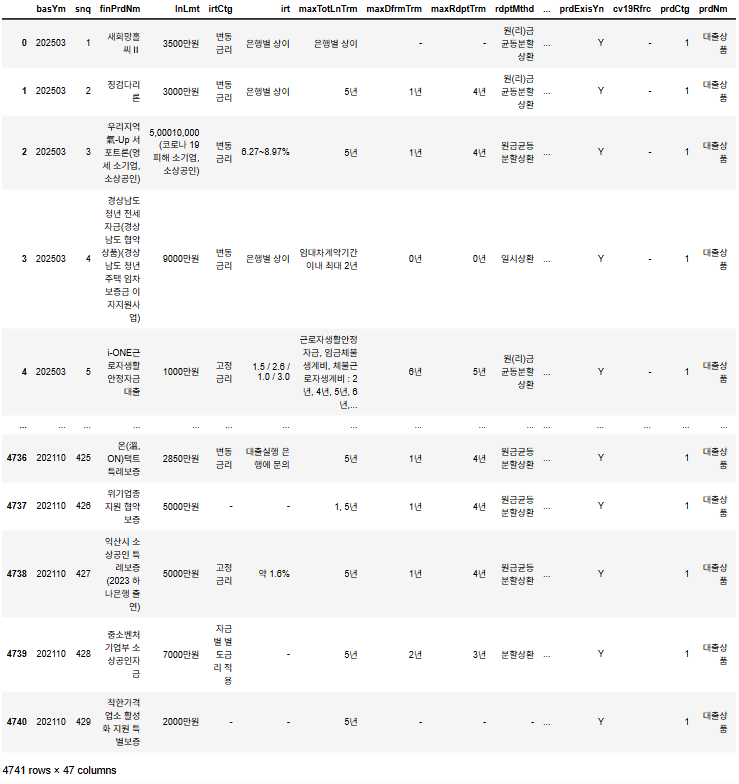

In [48]:
totalCount

4741

In [46]:
keys

['response',
 'header',
 'resultCode',
 'resultMsg',
 'body',
 'numOfRows',
 'pageNo',
 'totalCount',
 'items',
 'item',
 'basYm',
 'snq',
 'finPrdNm',
 'lnLmt',
 'irtCtg',
 'irt',
 'maxTotLnTrm',
 'maxDfrmTrm',
 'maxRdptTrm',
 'rdptMthd',
 'usge',
 'trgt',
 'instCtg',
 'ofrInstNm',
 'rsdAreaPamtEqltIstm',
 'suprTgtDtlCond',
 'age',
 'incm',
 'rsdArea',
 'crdtSc',
 'anin',
 'housHoldCnt',
 'housAr',
 'lnTgtHous',
 'rfrcCnpl',
 'grnInst',
 'jnMthd',
 'rpymdCfe',
 'lnIcdcst',
 'ovItrYr',
 'prftAddIrtCond',
 'etcRefSbjc',
 'hdlInst',
 'cnpl',
 'rltSite',
 'tgtFltr',
 'hdlInstDtlVw',
 'prdExisYn',
 'cv19Rfrc',
 'prdCtg',
 'prdNm',
 'cv19SuprCtg',
 'cv19SuprCtn',
 'cv19SuprTgtDtlCtn',
 'mgmDln',
 'prdCtg2',
 'fileWrtDt']

In [34]:
key_list = {}
for item in soup.select("*"):
    key_list.setdefault(item.name, "")
key_list = list(key_list.keys())
key_list

['response',
 'header',
 'resultCode',
 'resultMsg',
 'body',
 'numOfRows',
 'pageNo',
 'totalCount',
 'items',
 'item',
 'basYm',
 'snq',
 'finPrdNm',
 'lnLmt',
 'irtCtg',
 'irt',
 'maxTotLnTrm',
 'maxDfrmTrm',
 'maxRdptTrm',
 'rdptMthd',
 'usge',
 'trgt',
 'instCtg',
 'ofrInstNm',
 'rsdAreaPamtEqltIstm',
 'suprTgtDtlCond',
 'age',
 'incm',
 'rsdArea',
 'crdtSc',
 'anin',
 'housHoldCnt',
 'housAr',
 'lnTgtHous',
 'rfrcCnpl',
 'grnInst',
 'jnMthd',
 'rpymdCfe',
 'lnIcdcst',
 'ovItrYr',
 'prftAddIrtCond',
 'etcRefSbjc',
 'hdlInst',
 'cnpl',
 'rltSite',
 'tgtFltr',
 'hdlInstDtlVw',
 'prdExisYn',
 'cv19Rfrc',
 'prdCtg',
 'prdNm',
 'cv19SuprCtg',
 'cv19SuprCtn',
 'cv19SuprTgtDtlCtn',
 'mgmDln',
 'prdCtg2',
 'fileWrtDt']

In [37]:
keys = key_list[10:]

In [40]:
soup.select("basYm")
soup.select("snq")

[<basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>]